# VLX-VR Cookbook

`VLX-VR` (Video Reasoning) is a cloud-edge collaborative deep reasoning model for complex video analysis. It locates key time segments around the user's question, integrates visual, temporal, textual, and numerical clues, performs cross-segment multi-step reasoning, and returns analysis results that can be reviewed.

VLX-VR is better suited to video file analysis where some waiting time is acceptable and complete semantic understanding is the priority. For continuous sampling, fast feedback, or real-time alerting, evaluate `VLX-Flow` first.

- Demo / playground: [om-agent.com](https://om-agent.com/)
- Paper: [arXiv:2609.09985](https://arxiv.org/abs/2609.09985)
- Official API doc (EN): [Om AI Developer Platform · VLX-VR Series](https://s.apifox.cn/d7fec0d2-c45b-493b-a1dd-825ad039f493/9507527m0)

> This notebook is a cookbook, not a model-training notebook. Get `{API_ENDPOINT}` from **API → Authentication**, and `{OM_API_KEY}` (access token) from **API → Access Tokens**.


## Capabilities and Boundaries

| Capability | Description |
| --- | --- |
| Key time-segment localization | Locates the video segments related to the question and conclusion. |
| Cross-segment event analysis | Explains how an event occurs and develops by combining changes in preceding and subsequent states. |
| Multi-step video reasoning | Organizes visual, temporal, numerical, and contextual clues to produce a natural-language conclusion. |
| Evidence review | Identifies key timestamps or video evidence in the answer to facilitate verification. |

VLX-VR is not a replacement for real-time video-stream detection, conventional object detection, object tracking, or alerting systems. Production use still requires business rules, detection/tracking, an alerting loop, human review, and validation with real-world samples. Model performance is affected by video duration, bitrate, clarity, resource configuration, and task complexity. Refer to the actual platform validation for specific limits.


## Public Benchmark Reference

In this public comparison on the MINERVA complex video reasoning benchmark, VLX-VR achieved an overall accuracy of `78.79%`. Under the original three video-duration groups, the accuracies were `76.70%` for videos shorter than 5 minutes, `78.73%` for videos from 5 to 15 minutes, and `80.92%` for videos longer than 15 minutes. Among samples answered correctly by the model, the consistency between the reasoning traces and the human reference traces and evidence descriptions was `96.20%`.

These figures apply only to the corresponding evaluation set, model version, and statistical definition. `96.20%` measures trace consistency among correctly answered samples; it does not represent the reliability rate for all video tasks. Validate the model with your own business samples.


## Model Experience

The model experience page supports platform-provided sample videos and local video uploads. Select a video and enter a natural-language question to start an analysis, for example:

```text
Summarize the key events in the video in chronological order and identify the corresponding time segments for each event.
```

Use the model experience page to quickly validate model behavior. For production integration, use the API/SDK instead and handle waiting, timeouts, retries, and result review in your application.


## API Prerequisites

The VLX-VR API/SDK **does not provide file upload functionality** and does not accept `file_id`, local file paths, or platform file-cabinet fields. You must first upload the video to your own object storage or file service, obtain a video URL that is accessible to the model service, and pass that URL in `video_url.url`.

Make sure that the video URL:

- Remains accessible during request processing and can be read by the platform service.
- Uses a protocol and video format supported by the platform.
- Does not depend on browser cookies, page login state, or a local network.
- Does not contain a long-lived plaintext secret that could be exposed to logs or third parties. If you use a signed URL, control its validity period.


## Credentials and Request URL

Cookbook examples below use **Bearer access-token** auth. Collect credentials from the Om AI developer platform as follows.

### 1. API endpoint (and optional AK/SK)

Path: **API → Authentication** (AK/SK Info).

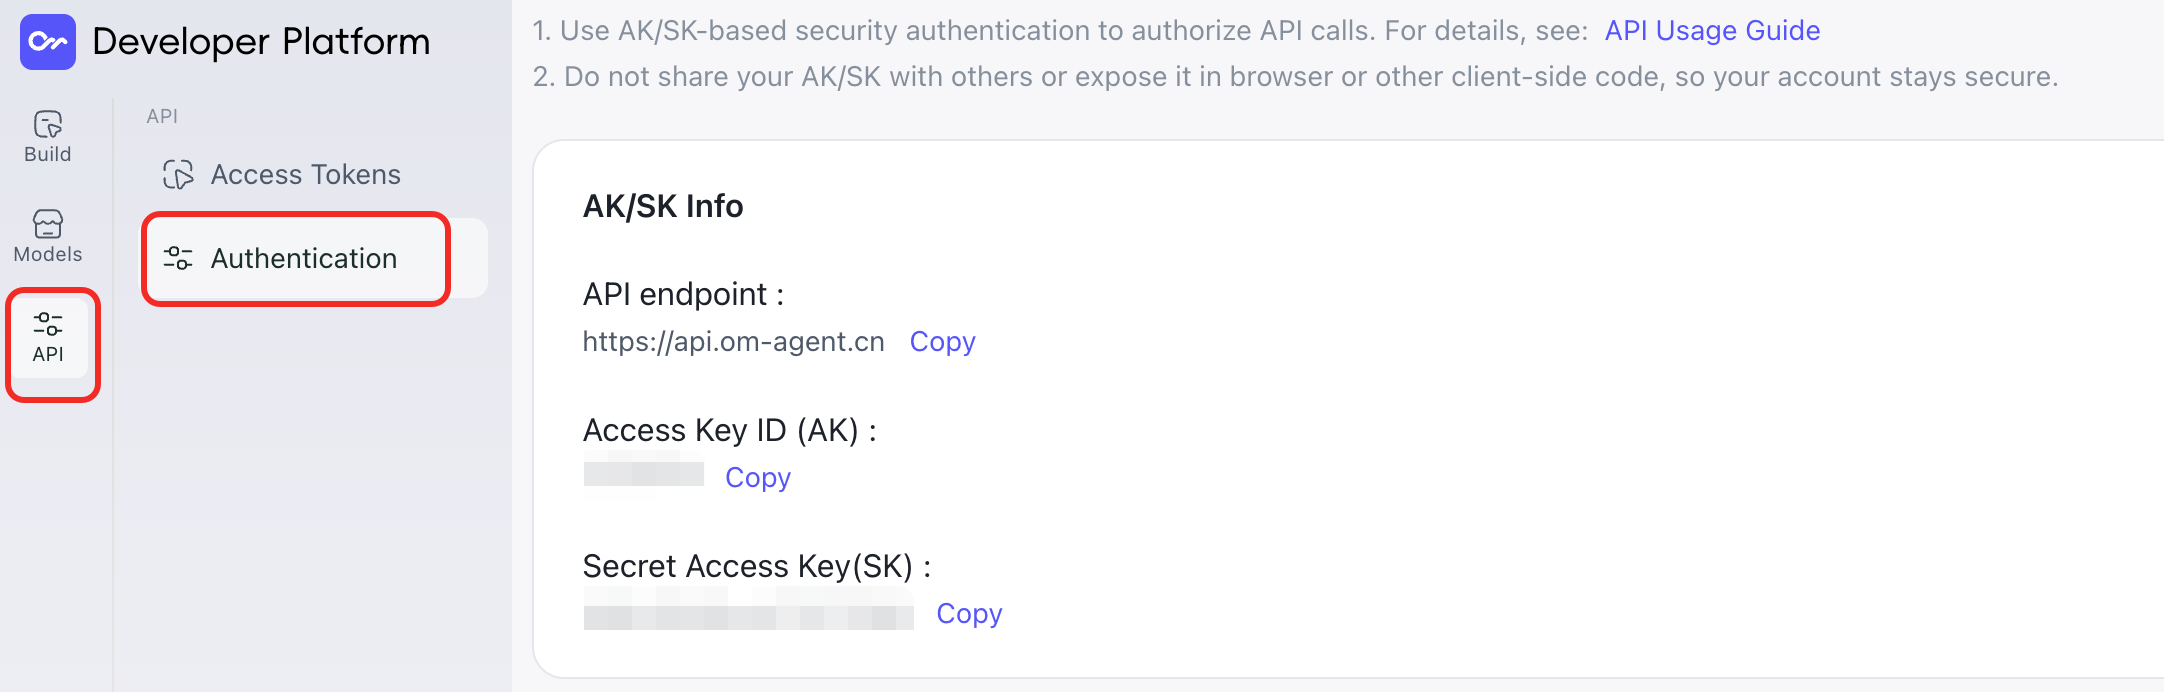

From this page, copy:

| Field | Use in this cookbook |
| --- | --- |
| **API endpoint** | `{API_ENDPOINT}` (example shown in console: `https://api.om-agent.cn`) |
| **Access Key ID (AK)** / **Secret Access Key (SK)** | For AK/SK signing flows described in the platform API Usage Guide (not used by the Bearer examples below) |

Do not share AK/SK with others or expose them in browser or other client-side code.

### 2. Access token (Bearer `{OM_API_KEY}`)

Path: **API → Access Tokens** → **+ Add**. Create a token, then copy the token value when it is shown (it may only be visible once).

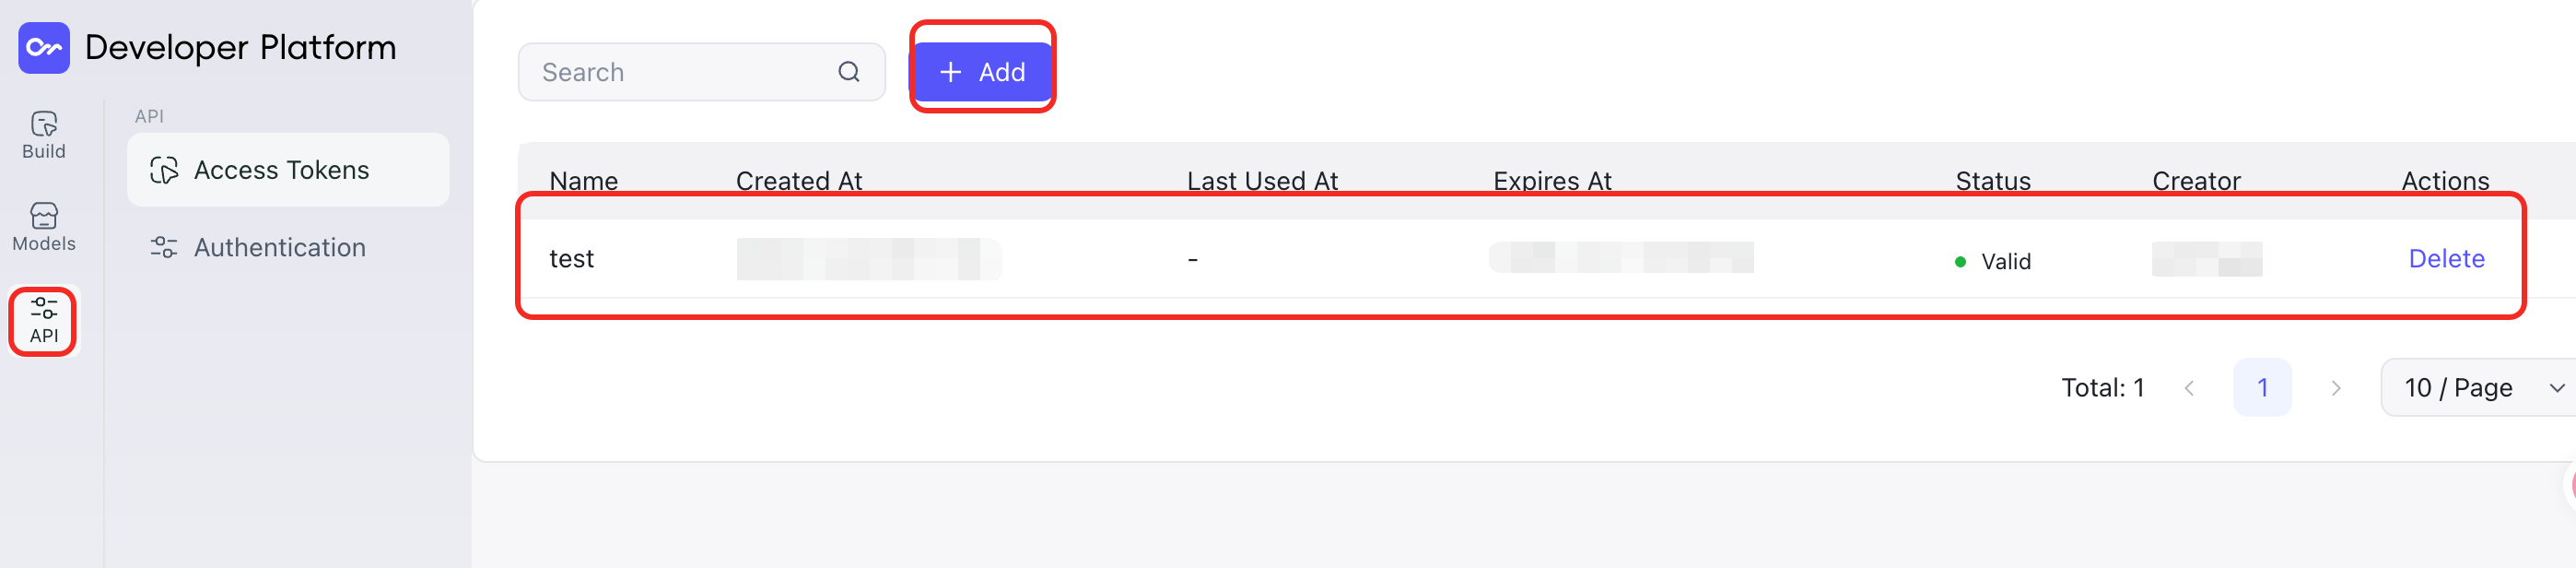

Use the generated access token as `{OM_API_KEY}` in:

```http
Authorization: Bearer {OM_API_KEY}
Content-Type: application/json
Accept: text/event-stream
```

Do not put access tokens in public code repositories, web frontends, logs, or screenshots.

### Request URL

```http
POST {API_ENDPOINT}/os/v2/vlx/vr/stream
```


## Request Parameters

| Field | Type | Required | Description |
| --- | --- | --- | --- |
| `model` | string | Yes | Must be `vlx-vr`; use the model ID currently displayed by the platform. |
| `messages` | array | Yes | OpenAI-style message list. The current interface uses a `user` message to pass the video and question. |
| `messages[].role` | string | Yes | Currently supports `user`; if `system` is enabled by the platform, follow the current model configuration. |
| `messages[].content` | string/array | Yes | Text or multimodal content blocks. Use an array when including a video. |
| `content[type=text].text` | string | Yes | The video analysis question, task instructions, or output constraints. |
| `content[type=video_url].video_url.url` | string | Yes | A video URL obtained after you upload or host the video yourself; at most one per request. |
| `stream` | boolean | No | The current endpoint returns SSE streaming output. `true` is recommended; if omitted, the platform default applies. |
| `temperature` | number | No | Controls output randomness. The current range is `0` to `2`; the default is `0.7` when omitted. |
| `thinking` | boolean | No | Whether to enable reasoning output. It must be enabled before using `reasoning_effort` as required by the interface. |
| `reasoning_effort` | string | No | Reasoning intensity. Allowed values are `low`, `medium`, `high`, and `max`; the default is `medium` when omitted. |

`top_p` is currently retained for compatibility and is not an effective tuning parameter. Do not pass internal `source`, `client_type`, top-level `type`, top-level `url`, `agentId`, `runId`, or workflow fields.


## Request Example

The following example assumes that the caller has already uploaded the video and obtained an accessible URL:


In [ ]:
# Fill from the Om AI developer console — do not hard-code secrets in shared notebooks.
# API_ENDPOINT  ← API → Authentication → "API endpoint"
# OM_API_KEY    ← API → Access Tokens → "+ Add" (Bearer access token)
import os

API_ENDPOINT = os.environ.get("OM_API_ENDPOINT", "{API_ENDPOINT}")
OM_API_KEY = os.environ.get("OM_API_KEY", "{OM_API_KEY}")
VIDEO_URL = os.environ.get(
    "VLX_VR_VIDEO_URL",
    "https://minio.om-agent.cn/goal/cover/tennis.mp4",
)

print("endpoint:", f"{API_ENDPOINT.rstrip('/')}/os/v2/vlx/vr/stream")
print("video:", VIDEO_URL)
print("access token set:", bool(OM_API_KEY) and not OM_API_KEY.startswith("{"))


In [ ]:
# Equivalent curl (export OM_API_ENDPOINT from Authentication, OM_API_KEY from Access Tokens):
curl_cmd = f"""
curl --location --request POST '{API_ENDPOINT}/os/v2/vlx/vr/stream' \\
  --header 'Accept: text/event-stream' \\
  --header 'Content-Type: application/json' \\
  --header "Authorization: Bearer $OM_API_KEY" \\
  --data-raw '{{
    "model": "vlx-vr",
    "messages": [
      {{
        "role": "user",
        "content": [
          {{
            "type": "text",
            "text": "Which side has the advantage in the match?"
          }},
          {{
            "type": "video_url",
            "video_url": {{
              "url": "{VIDEO_URL}"
            }}
          }}
        ]
      }}
    ],
    "stream": true,
    "temperature": 0.7,
    "thinking": true,
    "reasoning_effort": "medium"
  }}'
""".strip()
print(curl_cmd)


## Streaming Response

The endpoint returns `text/event-stream`. Read each `data:` message as an SSE event and use the `id` from the same request to correlate the frames.

### First Frame

```text
data: {"id":"chatcmpl_xxx","object":"chat.completion.chunk","choices":[{"index":0,"delta":{"reasoning_content":"","content":""}}]}
```

### Reasoning Delta Frame

When the endpoint returns a reasoning delta, the content is in `choices[0].delta.reasoning_content`. This field is provided to display the model's analysis process and must not be treated as a business conclusion or proof of absolute correctness.

```text
data: {"id":"chatcmpl_xxx","object":"chat.completion.chunk","choices":[{"index":0,"delta":{"reasoning_content":"I am checking the key time segments in the video.","content":""}}]}
```

### Answer Delta Frame

The final answer delta is in `choices[0].delta.content`:

```text
data: {"id":"chatcmpl_xxx","object":"chat.completion.chunk","choices":[{"index":0,"delta":{"reasoning_content":"","content":"A key event occurs from 00:18 to 00:26 in the video."}}]}
```

### Completion Frame

When processing completes normally, the endpoint first returns a content-completion frame and then `[DONE]`. The current public wrapper uses an empty `choices` array to indicate content completion:

```text
data: {"id":"chatcmpl_xxx","object":"chat.completion.chunk","choices":[]}

data: [DONE]
```

Different versions may add public request metadata, but callers are not expected to process internal Agent, workflow, plugin, or file-cabinet fields. Refer to the actual response and version notes for the current interface.

### Public Response Fields

| Field | Description |
| --- | --- |
| `id` | The public request ID for this call. It remains consistent across all SSE frames for the same call. |
| `object` | The streaming response object type, usually `chat.completion.chunk`. |
| `choices[0].delta.reasoning_content` | Reasoning delta text; it may be an empty string or omitted when unavailable. |
| `choices[0].delta.content` | Final answer delta text; callers should treat it as the business answer. |
| `choices` | An empty array in the content-completion frame; refer to the actual response for the current version. |
| `[DONE]` | The SSE end marker; it is not a JSON object. |


In [ ]:
import json
import requests

url = f"{API_ENDPOINT.rstrip('/')}/os/v2/vlx/vr/stream"
headers = {
    # OM_API_KEY = access token from API → Access Tokens
    "Authorization": f"Bearer {OM_API_KEY}",
    "Content-Type": "application/json",
    "Accept": "text/event-stream",
}
payload = {
    "model": "vlx-vr",
    "messages": [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Summarize the key events in the video in chronological order and identify the corresponding time segments for each event.",
                },
                {"type": "video_url", "video_url": {"url": VIDEO_URL}},
            ],
        }
    ],
    "stream": True,
    "temperature": 0.7,
    "thinking": True,
    "reasoning_effort": "medium",
}

request_id = None
reasoning_parts = []
answer_parts = []

# Skip the live call until credentials are configured.
if OM_API_KEY.startswith("{") or API_ENDPOINT.startswith("{"):
    print("Set OM_API_ENDPOINT and OM_API_KEY in the environment, then re-run this cell.")
else:
    with requests.post(url, headers=headers, json=payload, stream=True, timeout=600) as resp:
        resp.raise_for_status()
        for raw_line in resp.iter_lines(decode_unicode=True):
            if not raw_line:
                continue
            if raw_line.startswith(":"):  # SSE comment / keepalive
                continue
            if not raw_line.startswith("data:"):
                continue
            data = raw_line[len("data:") :].strip()
            if data == "[DONE]":
                break
            frame = json.loads(data)
            request_id = request_id or frame.get("id")
            choices = frame.get("choices") or []
            if not choices:
                continue  # content-completion frame in current public wrapper
            delta = (choices[0] or {}).get("delta") or {}
            if delta.get("reasoning_content"):
                reasoning_parts.append(delta["reasoning_content"])
                print(delta["reasoning_content"], end="", flush=True)
            if delta.get("content"):
                answer_parts.append(delta["content"])
                print(delta["content"], end="", flush=True)

    print("\n---")
    print("request_id:", request_id)
    print("answer:\n", "".join(answer_parts))


## Stop Running

When a user cancels, a page closes, or the business no longer needs the result, call the stop endpoint:

```http
POST {API_ENDPOINT}/os/v2/vlx/vr/stop
```

Request headers:

```http
Authorization: Bearer {OM_API_KEY}
Content-Type: application/json
```

Use the public request ID returned in the first streaming frame as the `id` in the request body:

```json
{
  "id": "chatcmpl_xxx"
}
```

The stop request must target only the public ID returned for the current call. Do not construct or pass an Agent `conversationId`, `chatId`, or `runId`.


In [ ]:
def stop_vlx_vr(request_id: str) -> dict:
    stop_url = f"{API_ENDPOINT.rstrip('/')}/os/v2/vlx/vr/stop"
    r = requests.post(
        stop_url,
        headers={
            "Authorization": f"Bearer {OM_API_KEY}",
            "Content-Type": "application/json",
        },
        json={"id": request_id},
        timeout=30,
    )
    r.raise_for_status()
    try:
        return r.json()
    except Exception:
        return {"status_code": r.status_code, "text": r.text}

# Example (after a live stream):
# stop_vlx_vr(request_id)


## Common Errors

| Scenario | Recommended handling |
| --- | --- |
| `model` does not exist or access is denied | Check that the model ID is `vlx-vr` and confirm the current user's access. |
| Video content is missing | Check that `messages[].content` contains one `video_url` content block. |
| The video URL is inaccessible | Validate the URL, protocol, signature validity period, and redirects from the service network. |
| The URL requires login state | Use an address directly accessible by the platform service; do not depend on cookies or a browser session. |
| The request times out or the task is still running | Save the first-frame `id`, then retry according to your timeout policy or call the stop endpoint. |
| The result does not match business expectations | Validate the prompt, video clarity, and key time segments with real samples, and retain human review. |

## Usage Boundaries

Public metrics and messaging for VLX-VR must be tied to the actual evaluation set, model version, and sample scope. Do not describe the model as a "pure on-device real-time model," "the global number one," or a model that can "directly replace security or industrial inspection systems." Do not interpret reasoning-trace consistency metrics as the reliability rate for all tasks.
